# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:Nurul alam
- Email: iyungalam5@gmail.com
- Id Dicoding:b https://www.dicoding.com/users/iyungalam/

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
!pip install squarify
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import squarify

### Menyiapkan data yang akan digunakan

In [2]:
# Melakukan import dataset
employee_df= pd.read_csv("https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv")

employee_df.head(10)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
5,6,29,NaN,Travel_Rarely,352,Human Resources,6,1,Medical,1,...,4,80,0,1,3,3,1,0,0,0
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,...,3,80,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,...,4,80,1,24,2,3,5,2,1,4
8,9,36,0.0,Travel_Frequently,635,Research & Development,18,1,Medical,1,...,1,80,0,8,2,3,8,1,1,7
9,10,32,0.0,Travel_Rarely,1018,Research & Development,3,2,Life Sciences,1,...,4,80,0,10,6,3,7,7,7,7


## Data Understanding

In [3]:
# mengecek ukuran data
employee_df.shape

(1470, 35)

In [4]:
# Mengecek tipe data dan missing value
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel



> terdapat data yang kosong / missing value di kolom attrition



In [5]:
employee_df.duplicated().sum()

np.int64(0)



> Tidak terdapat duplicate data pada dateset tersebut



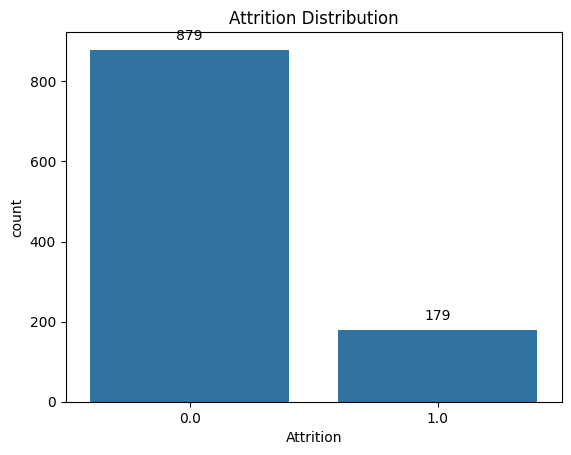

In [6]:
# attrition Distribution
ax = sns.countplot(data = employee_df, x = 'Attrition')
ax.set_title('Attrition Distribution')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()



> Secara sebarannya sebanyak 879 karyawan yang masih aktif dan sebanyak 179 yang tidak aktif pada perusahaan jaya jaya maju




## Data Preparation / Preprocessing

Menghapus data yang kosong dalam kolom attrition

In [7]:
#menghapus data yang kosong dalam attrition
employee_df.dropna(inplace = True)

employee_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1058 non-null   int64  
 1   Age                       1058 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1058 non-null   object 
 4   DailyRate                 1058 non-null   int64  
 5   Department                1058 non-null   object 
 6   DistanceFromHome          1058 non-null   int64  
 7   Education                 1058 non-null   int64  
 8   EducationField            1058 non-null   object 
 9   EmployeeCount             1058 non-null   int64  
 10  EnvironmentSatisfaction   1058 non-null   int64  
 11  Gender                    1058 non-null   object 
 12  HourlyRate                1058 non-null   int64  
 13  JobInvolvement            1058 non-null   int64  
 14  JobLevel     

In [8]:
employee_df.nunique()

,0
EmployeeId,1058
Age,43
Attrition,2
BusinessTravel,3
DailyRate,731
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1


Menghilangkan tabel yang tidak diperlukan dan memilih tabel yang diperlukan

In [10]:
# List kolom yang ingin dipertahankan
selected_columns = ["EmployeeId","Attrition", "Status","Gender", "Education", "EducationField",
                    "Edutxt", "JobLevel", "Department", "JobRole","MonthlyIncome", "SalaryCategory",
                    "PercentSalaryHike", "TotalWorkingYears","OverTime", "MaritalStatus", "PerformanceRating"]

# Mendapatkan list kolom yang akan dihapus
columns_to_drop = [col for col in employee_df.columns if col not in selected_columns]

# Menghapus kolom menggunakan drop()
employee_df = employee_df.drop(columns=columns_to_drop)

# Menampilkan 10 baris pertama untuk verifikasi
employee_df.head(10)

,EmployeeId,Attrition,Department,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,PerformanceRating,TotalWorkingYears
1,2,1.0,Research & Development,2,Medical,Female,2,Healthcare Representative,Married,4777,No,15,3,15
2,3,1.0,Research & Development,4,Life Sciences,Male,1,Research Scientist,Married,2461,Yes,12,3,18
3,4,0.0,Sales,3,Marketing,Female,4,Sales Executive,Married,13525,No,14,3,23
6,7,0.0,Sales,2,Medical,Male,2,Sales Executive,Married,7457,Yes,22,4,6
7,8,1.0,Research & Development,3,Medical,Male,5,Manager,Married,19859,Yes,13,3,24
8,9,0.0,Research & Development,1,Medical,Female,1,Laboratory Technician,Single,2153,No,13,3,8
9,10,0.0,Research & Development,2,Life Sciences,Female,3,Research Director,Single,11159,No,15,3,10
10,11,0.0,Sales,1,Marketing,Male,2,Sales Executive,Married,4256,No,12,3,5
11,12,1.0,Research & Development,3,Technical Degree,Male,1,Laboratory Technician,Single,2973,No,19,3,1
13,14,0.0,Research & Development,5,Life Sciences,Female,4,Research Director,Single,15992,No,14,3,16


Mengkategorikan dan memberikan label pada kolom agar lebih muda di interpretasikan

In [11]:
employee_df["Status"] = employee_df.Attrition.apply(lambda x: "Active" if x == 0 else "Inactive")
employee_df["Edutxt"] = employee_df.Education.apply(lambda x: "Below College" if x == 1
                                                      else ("College" if x == 2
                                                            else ("Bachelor" if x == 3
                                                                  else ("Master" if x == 4
                                                                        else "Doctor"))))
employee_df["SalaryCategory"] = employee_df["MonthlyIncome"].apply(lambda x: "Under 5000" if x < 5000
                                                      else ("5000-9999" if (x >= 5000 and x<9999)
                                                            else ("10000-14999" if (x >= 10000 and x<15000)
                                                                  else "Above 15000")))

## EDA & Visualization

1. Berapa jumlah pekerja di perusahaan Jaya Jaya Maju

In [12]:
# Jumlah total karyawan tahun ini
employee_total = len(employee_df["EmployeeId"])
print("Jumlah karyawan tahun ini adalah " + str(employee_total) + " orang.")

Jumlah karyawan tahun ini adalah 1058 orang.


2. Perbandingan jumlah karyawan yang aktif dan yang tidak aktif

In [13]:
employee_status = employee_df.groupby(by = ["Status"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["EmployeeId"], ascending = True)
employee_status = employee_status.reset_index()
employee_status = employee_status.rename(columns = {"EmployeeId":"Total"})
employee_status

,Status,Total
0,Inactive,179
1,Active,879




> diketahui bahwa jumlah karyawan yang aktif sebanyak 879 dan yang sudah tidak aktif sebanyak 179



([<matplotlib.patches.Wedge at 0x79089069a510>,
 [Text(0.9482430530482364, 0.5575258849109697, 'Inactive'),
  Text(-0.948242904614343, -0.5575261373680648, 'Active')],
 [Text(0.5172234834808561, 0.3041050281332562, '17%'),
  Text(-0.5172234025169143, -0.3041051658371262, '83%')])

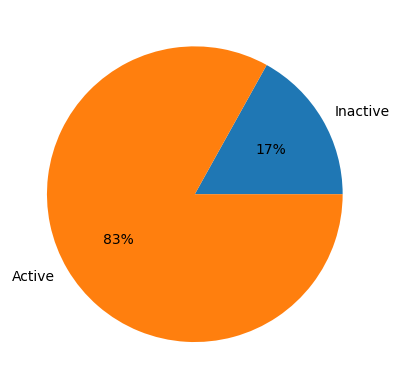

In [14]:
plt.pie(employee_status["Total"], autopct="%.0f%%", labels = employee_status["Status"])



> Sebanyak 17% karyawan yang keluar/tidak aktif di perusahaan jaya jaya maju dan 83% yang aktif




3. Bagaimana perbandingan jumlah karyawan berdasarkan gender dan statusnya?

In [15]:
# Membuat tabel cross-tabulation
employee_gender_status = employee_df.groupby(['Gender', 'Status'])['EmployeeId'].count().reset_index(name='Total')

# Menampilkan tabel
display(employee_gender_status)

,Gender,Status,Total
0,Female,Active,367
1,Female,Inactive,71
2,Male,Active,512
3,Male,Inactive,108


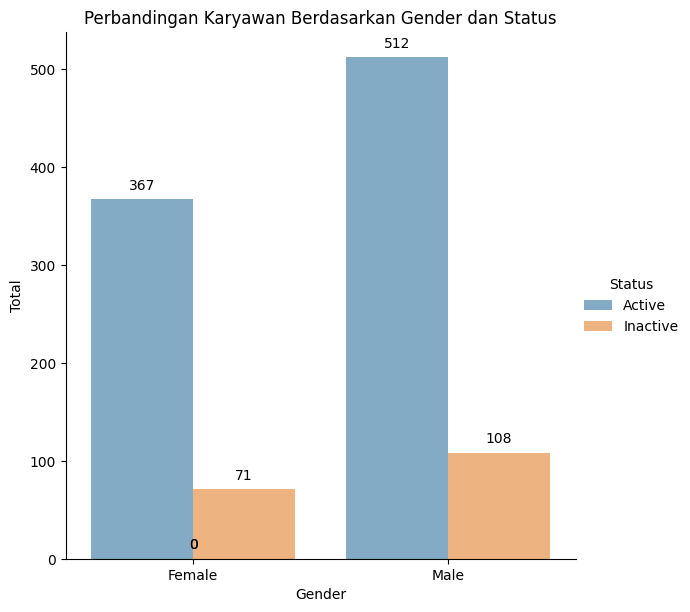

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt


# Membuat Grouped Bar Chart
ax = sns.catplot(data=employee_gender_status, kind="bar",
    x="Gender", y="Total", hue="Status",
    errorbar="sd", alpha=.6, height=6)
plt.title("Perbandingan Karyawan Berdasarkan Gender dan Status")

# Menambahkan label angka pada bar
for p in ax.ax.patches:
    ax.ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10), textcoords='offset points')

plt.show()



> Jumlah karyawan di perusahaan jaya jaya maju di dominasi oleh laki-laki sebanyak 512 dibandingkan perempuan 367. akan tetapi, jumlah karyawan yang keluar juga lebih banyak laki-laki sebanyak 108 karyawan dibanding dengan perempuan yang hanya 71 karyawan.



4. Bagaimana sebaran tingkatan pendidikan karyawan?

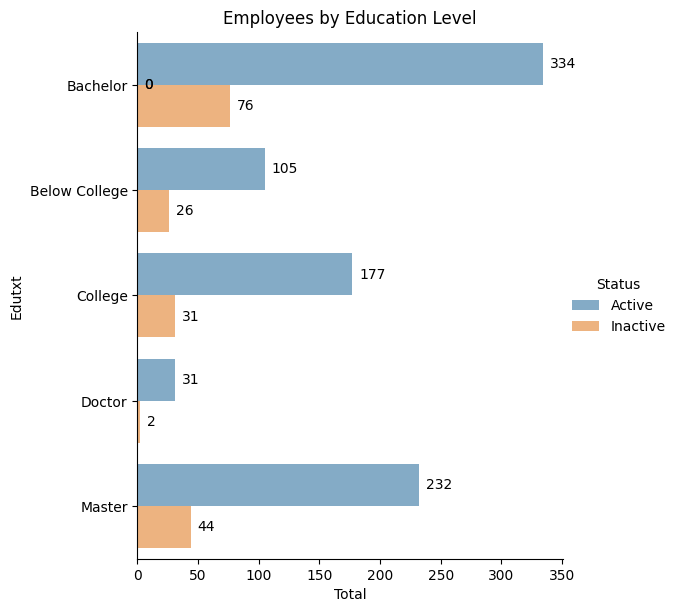

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

employee_education_status = employee_df.groupby(by=["Edutxt", "Status"])["EmployeeId"].count().reset_index(name="Total")

# Membuat catplot
g = sns.catplot(
    data=employee_education_status, kind="bar",
    y="Edutxt", x="Total", hue="Status", orient="h",
    errorbar="sd", alpha=.6, height=6)
plt.title("Employees by Education Level")

# Menambahkan label angka pada bar
ax = g.facet_axis(0, 0)  # Mengakses axes dari catplot
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}',  # Mengambil nilai width untuk orientasi 'h'
                   (p.get_width(), p.get_y() + p.get_height() / 2.), # Menentukan posisi label
                   ha='left', va='center',  # Mengatur alignment label
                   xytext=(5, 0), textcoords='offset points')  # Mengatur offset label

plt.show()  # Menampilkan grafik



> Karyawan terbanyak di perusaahaan jaya jaya maju adalah lulusan sarjana sebanyak 334 karyawan dan karyawan terbanyak yang keluar dari perusahaan pun lulusan sarjana sebanyak 76 karyawan



5. Bagaimana sebaran bidang pendidikan yang ditempuh karyawan

In [18]:
employee_edufield = employee_df.groupby(by = ["EducationField"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["EmployeeId"], ascending = True)
employee_edufield = employee_edufield.reset_index()
employee_edufield = employee_edufield.rename(columns = {"EmployeeId":"Total"})
employee_edufield

,EducationField,Total
0,Human Resources,15
1,Other,59
2,Technical Degree,96
3,Marketing,122
4,Medical,330
5,Life Sciences,436


In [19]:
# Menghitung jumlah karyawan per EducationField dan Status, lalu reset index dan rename kolom
edufield_status_counts = employee_df.groupby(['EducationField', 'Status'])['EmployeeId'].count().reset_index(name='Total_Employees')

# Menampilkan DataFrame
edufield_status_counts

,EducationField,Status,Total_Employees
0,Human Resources,Active,13
1,Human Resources,Inactive,2
2,Life Sciences,Active,366
3,Life Sciences,Inactive,70
4,Marketing,Active,96
5,Marketing,Inactive,26
6,Medical,Active,284
7,Medical,Inactive,46
8,Other,Active,49
9,Other,Inactive,10


<ipython-input-23-6837d55c374e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total', y='EducationField', data=employee_edufield, palette='viridis')


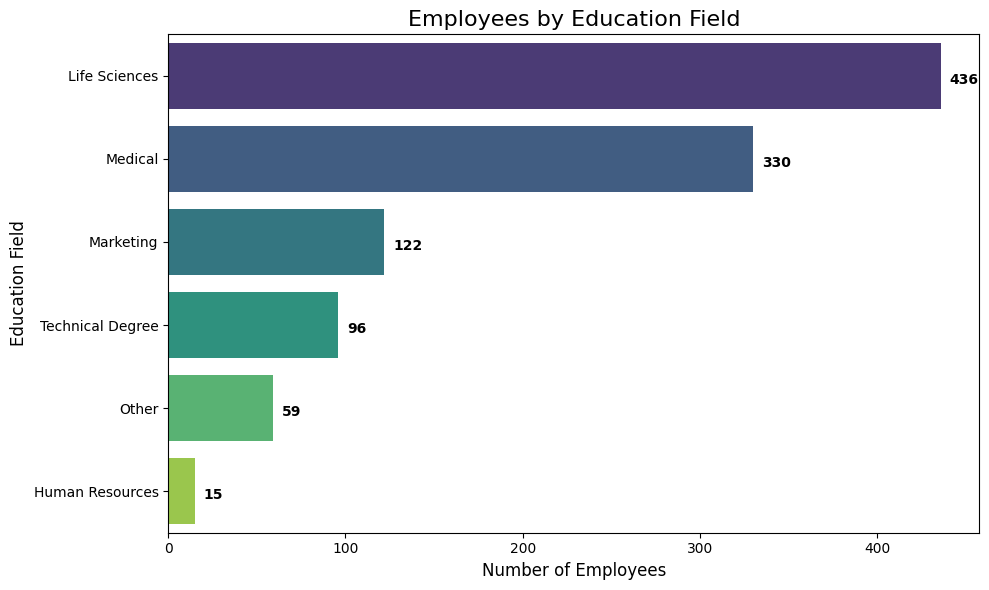

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Urutkan data berdasarkan Total karyawan (descending) untuk tampilan yang lebih baik
employee_edufield = employee_edufield.sort_values(by=['Total'], ascending=False)

plt.figure(figsize=(10, 6))  # Atur ukuran gambar
sns.barplot(x='Total', y='EducationField', data=employee_edufield, palette='viridis')
plt.title('Employees by Education Field', fontsize=16)
plt.xlabel('Number of Employees', fontsize=12)
plt.ylabel('Education Field', fontsize=12)

# Menambahkan label angka pada bar
for i, v in enumerate(employee_edufield['Total']):
    plt.text(v + 5, i + .1, str(v), color='black', fontweight='bold')

plt.tight_layout()
plt.show()



> Secara keseluruhan, karyawan paling banyak di dominasi oleh bidang life science 436, akan tetapi jumlah aktif sebanyak 366 dan yang tidak aktif 70 karyawan. bidang tersebut paling terbanyak di banding dengan bidang lainnya.



6. Bagaimana sebaran department karyawan?

In [23]:
employee_department = employee_df.groupby(by = ["Department"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["EmployeeId"], ascending = True)
employee_department = employee_department.reset_index()
employee_department = employee_department.rename(columns = {"EmployeeId":"Total"})
employee_department

,Department,Total
0,Human Resources,38
1,Sales,319
2,Research & Development,701


In [24]:
employee_department_status = employee_df.groupby(by = ["Department","Status"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["Department"], ascending = True)
employee_department_status = employee_department_status.reset_index()
employee_department_status = employee_department_status.rename(columns = {"EmployeeId":"Total"})
employee_department_status


,Department,Status,Total
0,Human Resources,Active,32
1,Human Resources,Inactive,6
2,Research & Development,Active,594
3,Research & Development,Inactive,107
4,Sales,Active,253
5,Sales,Inactive,66


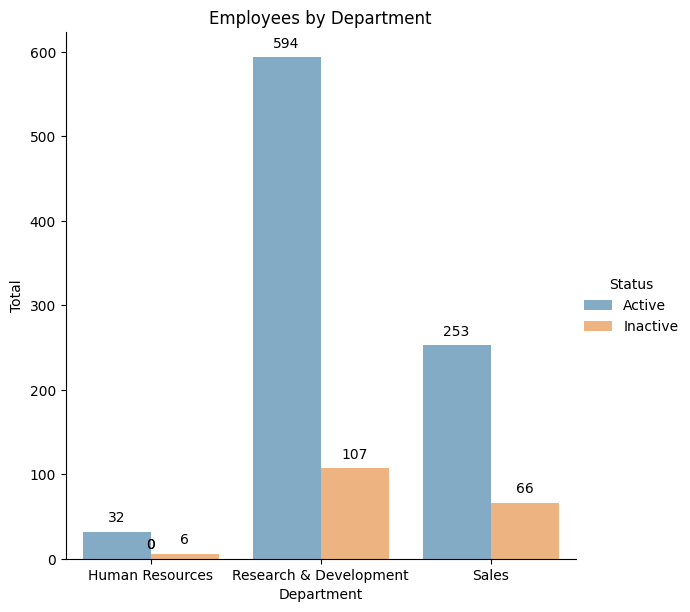

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

# 6. Bagaimana sebaran department karyawan?
employee_department = employee_df.groupby(by = ["Department"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["EmployeeId"], ascending = True)
employee_department = employee_department.reset_index()
employee_department = employee_department.rename(columns = {"EmployeeId":"Total"})
employee_department

employee_department_status = employee_df.groupby(by = ["Department","Status"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["Department"], ascending = True)
employee_department_status = employee_department_status.reset_index()
employee_department_status = employee_department_status.rename(columns = {"EmployeeId":"Total"})
employee_department_status

# Membuat Grouped Bar Chart dengan label angka
ax = sns.catplot(
    data=employee_department_status, kind="bar",
    x="Department", y="Total", hue="Status",
    errorbar="sd", alpha=.6, height=6)
plt.title("Employees by Department")

# Menambahkan label angka pada bar
for p in ax.ax.patches:
    ax.ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10), textcoords='offset points')

plt.show()




> Secara keseluruhan, total departemen research & development lebih banyak di bandingkan dengan departemen lainnya. akan tetapi departemen rnd juga yang paling banyak karyawan keluar dari perushaan.



7. Bagaimana sebaran Jabatan Karyawan?

In [26]:
employee_jobrole = employee_df.groupby(by = ["JobRole"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["EmployeeId"], ascending = True)
employee_jobrole = employee_jobrole.reset_index()
employee_jobrole = employee_jobrole.rename(columns = {"EmployeeId":"Total"})
employee_jobrole

,JobRole,Total
0,Human Resources,30
1,Sales Representative,58
2,Research Director,62
3,Manager,79
4,Healthcare Representative,88
5,Manufacturing Director,107
6,Laboratory Technician,188
7,Research Scientist,214
8,Sales Executive,232


In [27]:
employee_jobrole_status = employee_df.groupby(by = ["JobRole","Status"] ).agg({"EmployeeId" : "count",
            }).sort_values(by = ["JobRole"], ascending = True)
employee_jobrole_status = employee_jobrole_status.reset_index()
employee_jobrole_status = employee_jobrole_status.rename(columns = {"EmployeeId":"Total"})
employee_jobrole_status

,JobRole,Status,Total
0,Healthcare Representative,Active,80
1,Healthcare Representative,Inactive,8
2,Human Resources,Active,24
3,Human Resources,Inactive,6
4,Laboratory Technician,Active,139
5,Laboratory Technician,Inactive,49
6,Manager,Active,74
7,Manager,Inactive,5
8,Manufacturing Director,Inactive,7
9,Manufacturing Director,Active,100


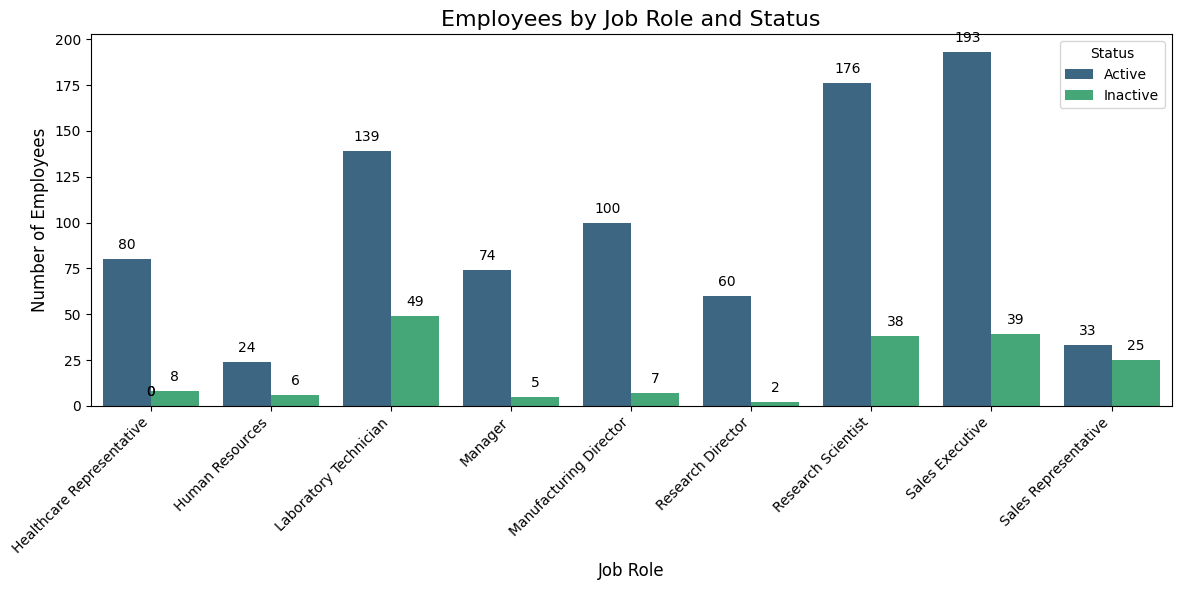

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Grouped Bar Chart
plt.figure(figsize=(12, 6))  # Atur ukuran gambar agar lebih lebar
ax = sns.barplot(
    data=employee_jobrole_status,
    x="JobRole",
    y="Total",
    hue="Status",
    palette="viridis"
)
plt.title("Employees by Job Role and Status", fontsize=16)
plt.xlabel("Job Role", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
# Menambahkan label angka pada bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10), textcoords='offset points',
                   fontsize=10)  # Ukuran font label angka

plt.tight_layout()
plt.show()



> Jabatan paling banyak terdapat pada jabatan Sales executive, akan tetapi jabatan paling banyak keluar ada pada jabatan laboratory technician



8. Bagaimana sebaran tingkat jabatan karyawan?

In [29]:
employee_joblevel_status = employee_df.groupby(by = ["JobLevel", "Status"] ).agg({"EmployeeId" : "count"
            }).sort_values(by = ["JobLevel"], ascending = False)
employee_joblevel_status = employee_joblevel_status.reset_index()
employee_joblevel_status = employee_joblevel_status.rename(columns = {"EmployeeId":"Total"})
employee_joblevel_status

,JobLevel,Status,Total
0,5,Inactive,5
1,5,Active,50
2,4,Active,76
3,4,Inactive,4
4,3,Active,140
5,3,Inactive,25
6,2,Active,327
7,2,Inactive,37
8,1,Inactive,108
9,1,Active,286


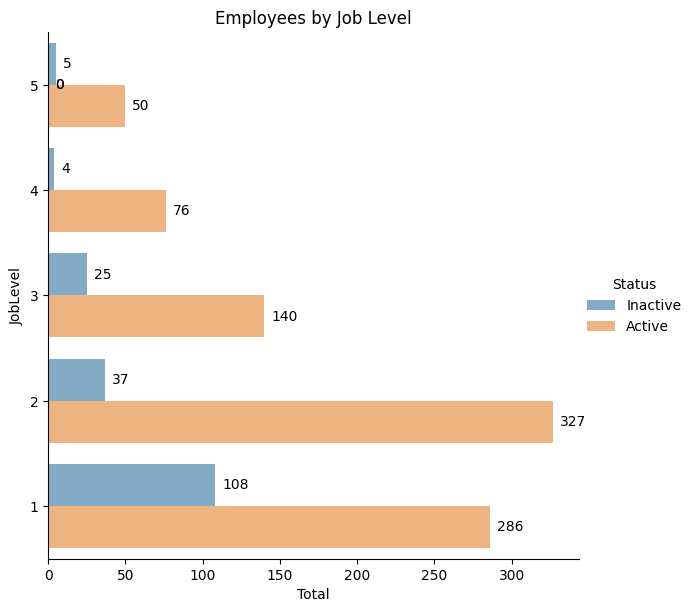

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat catplot
g = sns.catplot(
    data=employee_joblevel_status, kind="bar",
    y="JobLevel", x="Total", hue="Status", orient="h",
    order=employee_joblevel_status["JobLevel"],
    errorbar="sd", alpha=.6, height=6)
plt.title("Employees by Job Level")

# Menambahkan label angka pada bar
ax = g.facet_axis(0, 0)  # Mengakses axes dari catplot
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}',  # Mengambil nilai width untuk orientasi 'h'
                   (p.get_width(), p.get_y() + p.get_height() / 2.), # Menentukan posisi label
                   ha='left', va='center',  # Mengatur alignment label
                   xytext=(5, 0), textcoords='offset points')  # Mengatur offset label

plt.show()  # Menampilkan grafik



> karyawan paling banyak di level 1 hingga 2 secara keseluruhan. dan paling banyak keluar dari perusahaan berada pada level 1



9. Bagaimana status pernikahan karyawan?

In [31]:
import pandas as pd

employee_marital_status = employee_df.groupby(['MaritalStatus', 'Status'])['EmployeeId'].count().reset_index(name='Total')

# Membuat pivot table
marital_status_pivot = pd.pivot_table(
    employee_marital_status,
    values='Total',
    index='MaritalStatus',
    columns='Status',
)

# Mengubah format angka, menampilkan desimal hanya jika ada
styled_table = marital_status_pivot.style.format("{:.0f}")

# Menampilkan pivot table dengan format yang diinginkan
styled_table

Status,Active,Inactive
MaritalStatus,,
Divorced,219,23
Married,402,62
Single,258,94


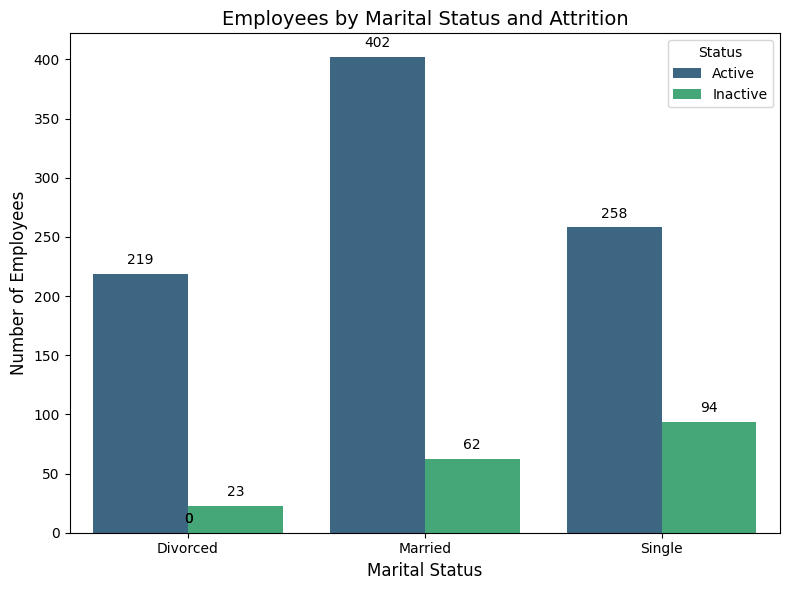

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Grouped Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=employee_marital_status,
    x="MaritalStatus",
    y="Total",
    hue="Status",
    palette="viridis"
)
plt.title("Employees by Marital Status and Attrition", fontsize=14)
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

# Menambahkan label angka pada bar (tanpa desimal)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',  # Mengubah format string di sini
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10), textcoords='offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()



> secara keseluruhan, karyawan di dominasi oleh karyawan yang sudah menikah. akan tetapi, karyawan yang mash single yang paling banyak keluar dari perusahaan




11. Berapa rata-rata gaji perbulan dan sebaran kategori penghasilan karyawan?

In [33]:
employee_df[["MonthlyIncome", "TotalWorkingYears"]].describe()

,MonthlyIncome,TotalWorkingYears
count,1058.000000,1058.000000
mean,6625.945180,11.435728
std,4837.695042,8.016429
min,1009.000000,0.000000
25%,2900.250000,6.000000
50%,4903.500000,10.000000
75%,8736.500000,16.000000
max,19999.000000,40.000000


In [34]:
# Menghitung jumlah karyawan per SalaryCategory dan Status, lalu reset index dan rename kolom
employee_salarycategory_status = employee_df.groupby(['SalaryCategory', 'Status'])['EmployeeId'].count().reset_index(name='Total')

# Menampilkan DataFrame
employee_salarycategory_status

,SalaryCategory,Status,Total
0,10000-14999,Active,102
1,10000-14999,Inactive,15
2,5000-9999,Active,262
3,5000-9999,Inactive,35
4,Above 15000,Active,97
5,Above 15000,Inactive,5
6,Under 5000,Active,418
7,Under 5000,Inactive,124


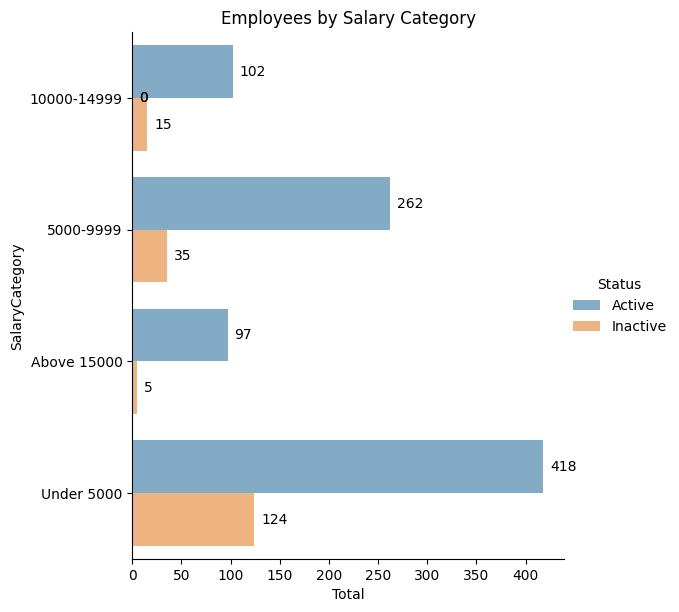

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat catplot
g = sns.catplot(
    data=employee_salarycategory_status, kind="bar",
    y="SalaryCategory", x="Total", hue="Status", orient="h",
    errorbar="sd", alpha=.6, height=6)
plt.title("Employees by Salary Category")

# Menambahkan label angka pada bar
ax = g.facet_axis(0, 0)  # Mengakses axes dari catplot
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}',  # Mengambil nilai width untuk orientasi 'h'
                   (p.get_width(), p.get_y() + p.get_height() / 2.),  # Menentukan posisi label
                   ha='left', va='center',  # Mengatur alignment label
                   xytext=(5, 0), textcoords='offset points')  # Mengatur offset label

plt.show()  # Menampilkan grafik



> Karyawan paling banyak menerima gaji di bawah rata-rata atau di bawah usd5000. Dan karyawan yang di gaji di bawah rata-rata paling banyak keluar dari perusahaan



12. Berapa rata-rata lama kerja karyawan di perusahaan?

In [36]:
employee_df[["TotalWorkingYears"]].describe()

,TotalWorkingYears
count,1058.000000
mean,11.435728
std,8.016429
min,0.000000
25%,6.000000
50%,10.000000
75%,16.000000
max,40.000000




> Rata-rata karyawan bekerja di perusahaan 11,4 tahun



13. Berapa banyak karyawan yang bekerja overtime?

In [37]:
# Menghitung jumlah karyawan per OverTime dan Status, lalu reset index dan rename kolom
employee_overtime_status = employee_df.groupby(['OverTime', 'Status'])['EmployeeId'].count().reset_index(name='Total')

# Menampilkan DataFrame
employee_overtime_status

,OverTime,Status,Total
0,No,Active,670
1,No,Inactive,81
2,Yes,Active,209
3,Yes,Inactive,98


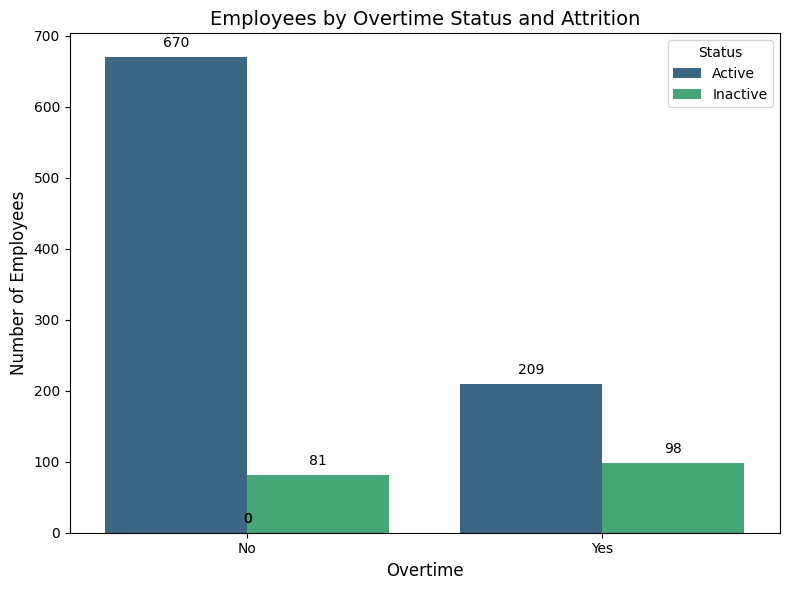

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Grouped Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=employee_overtime_status,
    x="OverTime",
    y="Total",
    hue="Status",
    palette="viridis"
)
plt.title("Employees by Overtime Status and Attrition", fontsize=14)
plt.xlabel("Overtime", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

# Menambahkan label angka pada bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10), textcoords='offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()



> karyawan yang memtuskan keluar dari perusahaan bekrja secara overtime



## KESIMPULAN dan SARAN

KESIMPULAN
- Secara total keseluruhan terdapat 1058 karyawan yang bekerja
- Terdapat 879 atau 83% karyawan yang masih aktif bekerja sedangkan 179 atau karyawan 17% memilih untuk keluar dari perusahann.
- Secara keseluruhan karyawan di dominasi oleh laki-laki, tetapi laki-laki juga yang paling banyak keluar dari perusahaan
- secara keseluruhan karyawan di dominasi oleh mereka yang sudah menikah, akan tetapi secara jumlah yang keluar lebih banyak mereka yang masih sigle
- secara keseluruhan karyawan di dominasi oleh lulusan sarjana dan lulusan sarjana juga yang paling banyak keluar dari perusahaan
- Secara keseluruhan departeman rnd yang paling banyak totak karyawan. akan tetapi, departemen rnd juga yang paling banyak keluar dari perusahaan.
- secara keseluruhan karyawan di dominasi oleh karyawan dengan bidang life science, akan tetapi bidang tersebut juga yang paling banyak karyawan yang keluar
- secara total karyawan palimg banyak pada jabatan sales executive, sedangkan yang paling banyak keluar pada bidang laboratory techincian
- secara keseluruhan gaji karyawan masih di bawah rata-rata atau di bawah USD5000 dan karyawan dengan gaji tersebut juga yang paling banyak keluar dari perusahaan.
- karyawan yang masih level 1 menyumbang karyawan yang paling banyak keluar dari perusahaan
- mereka yang bekerja secara overtime yang paling banyak keluar dari perusahaan.


SARAN:
*Tingkat attrition yang tinggi pada perusahaan Jaya Jaya Maju memerlukan perhatian. Berdasarkan data, karyawan level 1 bergaji rendah, single, di departemen R&D dan bidang Life Science, serta yang bekerja lembur, memiliki kecenderungan lebih tinggi untuk keluar. Untuk mengatasinya, perusahaan perlu fokus pada beberapa strategi.*

1. Meningkatkan Kesejahteraan Karyawan, Terutama Level dan Bergaji Rendah, Kesimpulan menunjukkan bahwa karyawan dengan gaji di bawah rata-rata (USD5000) dan level 1 memiliki tingkat attrition yang tinggi.
2. Fokus pada Retensi Karyawan di Departemen R&D dan Bidang Life Science, Departemen R&D dan bidang Life Science memiliki jumlah karyawan terbanyak, namun juga memiliki attrition rate yang tinggi.
3. Memberikan Perhatian Lebih kepada Karyawan Single, Meskipun didominasi oleh karyawan yang sudah menikah, karyawan single memiliki tingkat attrition yang lebih tinggi.
4. Mengurangi kerjaan secara overtime kepada karyawan

Departemen R&D dan bidang Life Science memiliki jumlah karyawan terbanyak, namun juga memiliki attrition rate yang tinggi.


In [39]:
employee_df.to_csv("employee_all.csv", index=False)